# Data Preview & Summary Statistics — HY & IG Target Series

Quick look at the raw weekly ETF price series used as forecasting targets: **HY (HYG)** and **IG (LQD)**. Shows a head/tail preview, descriptive statistics on both price levels and weekly returns, and a time-series plot. Tables and the chart are inline so they can be saved or screenshotted directly.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().resolve()))
from _helpers import project_root_from_cwd
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

root = project_root_from_cwd()
hy = pd.read_parquet(root / 'data/raw/targets/HY.parquet').squeeze('columns').rename('HY (HYG)')
ig = pd.read_parquet(root / 'data/raw/targets/IG.parquet').squeeze('columns').rename('IG (LQD)')
df = pd.concat([hy, ig], axis=1)
df.index.name = 'date'
print(f'Frequency: weekly | Range: {df.index.min().date()} → {df.index.max().date()} | N = {len(df)}')
df.shape

Frequency: weekly | Range: 2008-01-06 → 2026-05-03 | N = 957


(957, 2)

## Data preview

In [2]:
display(Markdown('### First 5 weeks'))
display(df.head().round(3))
display(Markdown('### Last 5 weeks'))
display(df.tail().round(3))

### First 5 weeks

,HY (HYG),IG (LQD)
date,,
2008-01-06,31.887,52.496
2008-01-13,31.469,52.451
2008-01-20,31.427,52.594
2008-01-27,31.710,52.895
2008-02-03,31.802,53.178


### Last 5 weeks

,HY (HYG),IG (LQD)
date,,
2026-04-05,79.145,108.694
2026-04-12,79.543,108.774
2026-04-19,80.230,109.610
2026-04-26,80.060,109.172
2026-05-03,79.712,108.305


## Summary statistics

In [3]:
display(Markdown('### Summary statistics — price levels'))
display(df.describe().round(3))

returns = df.pct_change().dropna() * 100  # weekly % returns
display(Markdown('### Summary statistics — weekly returns (%)'))
display(returns.describe().round(3))

### Summary statistics — price levels

,HY (HYG),IG (LQD)
count,957.000,957.000
mean,52.835,84.024
std,13.572,17.912
min,22.094,41.902
25%,43.642,72.145
50%,53.622,86.139
75%,62.628,98.824
max,80.230,113.151


### Summary statistics — weekly returns (%)

,HY (HYG),IG (LQD)
count,956.000,956.000
mean,0.108,0.084
std,1.563,1.267
min,-17.245,-13.255
25%,-0.385,-0.417
50%,0.165,0.175
75%,0.628,0.655
max,11.978,14.699


## Time-series plot

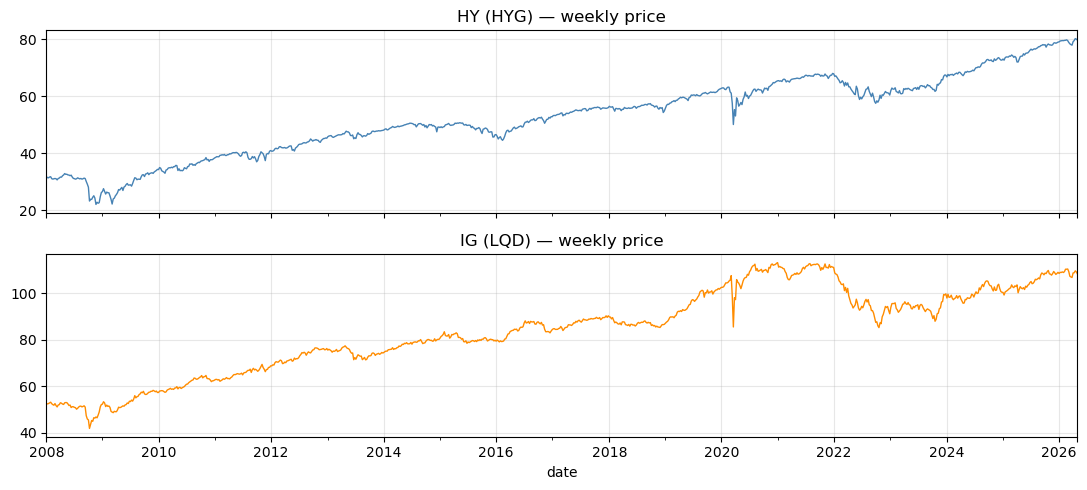

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
df['HY (HYG)'].plot(ax=axes[0], color='steelblue', lw=1.0)
axes[0].set_title('HY (HYG) — weekly price')
axes[0].grid(alpha=0.3)
df['IG (LQD)'].plot(ax=axes[1], color='darkorange', lw=1.0)
axes[1].set_title('IG (LQD) — weekly price')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()